In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.io import wavfile

In [2]:
plt.style.use('grayscale')

In [3]:
os.listdir('xenobirds')

['Blackbird',
 'Chaffinch',
 'Dunnock',
 'Goldfinch',
 'Linnet',
 'Robin',
 'Rook',
 'Starling',
 'Stonechat',
 'Wren',
 'Yellowhammer']

In [4]:
base_folder = 'xenobirds'
sav_folder  = f'{base_folder}_spec_images'
audio_paths = []
for bird_class in os.listdir(base_folder):
    class_sub = os.path.join(base_folder, bird_class)
    audio_paths.extend([os.path.join(class_sub, f) for f in os.listdir(class_sub)])

In [5]:
if not os.path.exists(sav_folder):
    os.mkdir(sav_folder)

In [6]:
audio_paths

['xenobirds\\Blackbird\\xc120750.wav',
 'xenobirds\\Blackbird\\xc142612.wav',
 'xenobirds\\Blackbird\\xc177025.wav',
 'xenobirds\\Blackbird\\xc177026.wav',
 'xenobirds\\Blackbird\\xc177027.wav',
 'xenobirds\\Blackbird\\xc191740.wav',
 'xenobirds\\Blackbird\\xc191741.wav',
 'xenobirds\\Blackbird\\xc19907.wav',
 'xenobirds\\Blackbird\\xc256567.wav',
 'xenobirds\\Blackbird\\xc407654.wav',
 'xenobirds\\Blackbird\\xc407857.wav',
 'xenobirds\\Blackbird\\xc422862.wav',
 'xenobirds\\Blackbird\\xc426986.wav',
 'xenobirds\\Blackbird\\xc426987.wav',
 'xenobirds\\Blackbird\\xc426988.wav',
 'xenobirds\\Blackbird\\xc444357.wav',
 'xenobirds\\Blackbird\\xc547611.wav',
 'xenobirds\\Blackbird\\xc547664.wav',
 'xenobirds\\Blackbird\\xc547776.wav',
 'xenobirds\\Blackbird\\xc641296.wav',
 'xenobirds\\Blackbird\\xc645056.wav',
 'xenobirds\\Blackbird\\xc648579.wav',
 'xenobirds\\Blackbird\\xc648601.wav',
 'xenobirds\\Blackbird\\xc648793.wav',
 'xenobirds\\Blackbird\\xc657658.wav',
 'xenobirds\\Blackbird\\xc

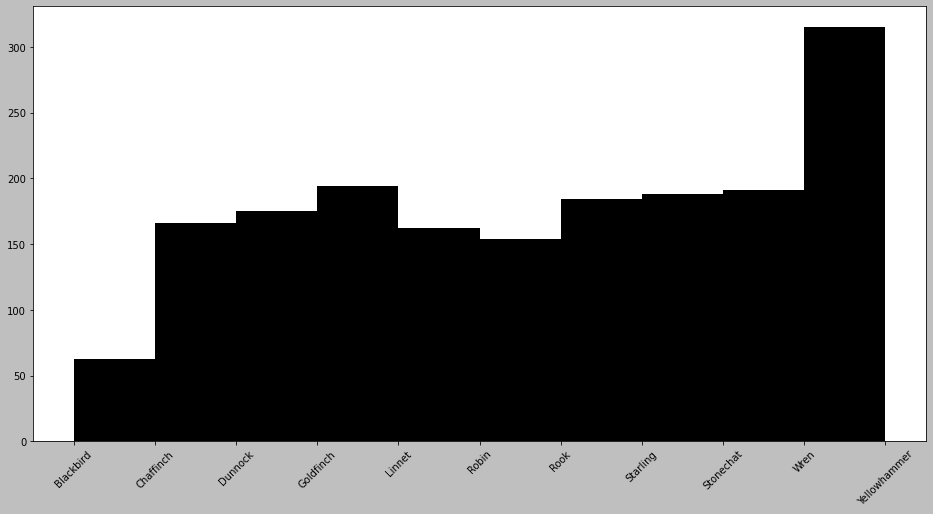

In [7]:
audio_classes = [f.split(os.path.sep)[-2] for f in audio_paths]
fig = plt.figure(figsize=(16, 8))
plt.hist(audio_classes)
plt.xticks(rotation=45)
plt.show()

In [8]:
def get_spectrogram(waveform, sr):
    # Zero-padding for an audio waveform with less than 16,000 samples.
    #input_len = 16000#len(waveform)
    if len(waveform.shape) == 2:
      waveform = waveform[:,0]
    waveform = waveform[:min(15*sr, len(waveform))]
    #zero_padding = tf.zeros(
    #  [input_len] - tf.shape(waveform),
    #  dtype=tf.float32)
    # Cast the waveform tensors' dtype to float32.
    waveform = tf.cast(waveform, dtype=tf.float32)
    # Concatenate the waveform with `zero_padding`, which ensures all audio
    # clips are of the same length.
    #equal_length = tf.concat([waveform, zero_padding], 0)
    # Convert the waveform to a spectrogram via a STFT.
    spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
    # Obtain the magnitude of the STFT.
    spectrogram = tf.abs(spectrogram)
    # Add a `channels` dimension, so that the spectrogram can be used
    # as image-like input data with convolution layers (which expect
    # shape (`batch_size`, `height`, `width`, `channels`).
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

In [9]:
def decode_audio(audio_binary):
    # Decode WAV-encoded audio files to `float32` tensors, normalized
    # to the [-1.0, 1.0] range. Return `float32` audio and a sample rate.
    audio, sr = tf.audio.decode_wav(contents=audio_binary)
    # Since all the data is single channel (mono), drop the `channels`
    # axis from the array.
    return tf.squeeze(audio, axis=-1), sr
def get_label(file_path):
    parts = file_path.split(os.path.sep)
    return parts[-2]
def get_waveform_and_label(file_path):
    label = get_label(file_path)
    sr, waveform = wavfile.read(file_path)
    #audio_binary = tf.io.read_file(file_path)
    #waveform,sr = decode_audio(audio_binary)
    return waveform, sr,label

In [10]:
from PIL import Image
def plot_spectrogram(spectrogram, ax):
    if len(spectrogram.shape) > 2:
        assert len(spectrogram.shape) == 3
        spectrogram = np.squeeze(spectrogram, axis=-1)
    # Convert the frequencies to log scale and transpose, so that the time is
    # represented on the x-axis (columns).
    # Add an epsilon to avoid taking a log of zero.
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)
def spec_imsave(I, filepath):
    plt.figure()
    plot_spectrogram(I, plt)
    plt.axis('off')
    plt.margins(x=0,y=0)
    #axes[1].set_title('Spectrogram')
    plt.savefig(filepath, bbox_inches='tight', pad_inches = 0)
    plt.close()

In [12]:
for f in audio_paths:
    file_split = f.split(os.path.sep)
    sav_name   = file_split[-1][:-4]+'_'+file_split[-2]+'.png'
    save_path  = os.path.join(sav_folder, sav_name)
    if os.path.exists(save_path):
        continue
    #print(sav_name)
    wf, sr, lab = get_waveform_and_label(f)
    spec = get_spectrogram(wf, sr)
    spec_imsave(spec.numpy()[:,:,0], save_path)

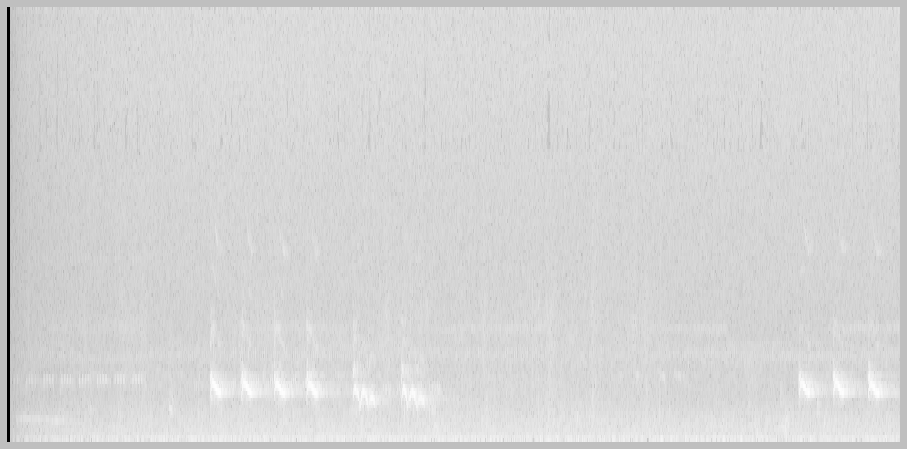

In [48]:
fig = plt.figure(figsize=(16, 8))
timescale = np.arange(wf.shape[0])
#axes[0].plot(timescale, waveform.numpy())
#axes[0].set_title('Waveform')
#axes[0].set_xlim([0, len(waveform)])

plot_spectrogram(spec, plt)
plt.axis('off')
plt.margins(x=0,y=0)
#axes[1].set_title('Spectrogram')
plt.show()